In [48]:
import pandas as pd
import numpy as np

In [49]:
df =pd.read_csv("housing.csv")

In [50]:
df["income_cat"]=pd.cut(df["median_income"],bins=[0,1.5,3.0,4.0,6.0,np.inf],labels=[1,2,3,4,5])

In [51]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [54]:
#Removing the Income Category(income_cat) column
for sett in (strat_train_set,strat_test_set):
    sett.drop("income_cat",axis=1 ,inplace=True)
    

In [57]:
df=strat_train_set.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

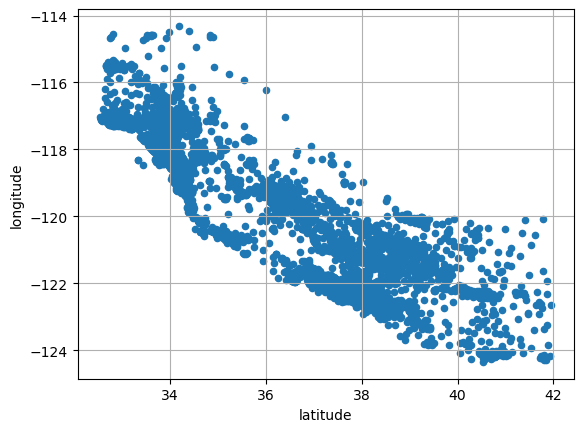

In [58]:
df.plot(kind="scatter" , x="latitude", y="longitude",grid=True)

<Axes: xlabel='latitude', ylabel='longitude'>

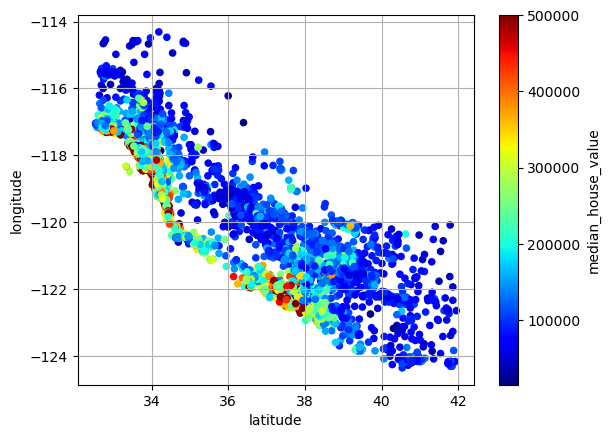

In [60]:
df.plot(kind="scatter" , x="latitude", y="longitude",grid=True ,cmap="jet",c="median_house_value")


In [63]:
df.drop(labels="ocean_proximity" , inplace=True,axis =1)
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924509,-0.112742,0.046833,0.074567,0.102619,0.058960,-0.018293,-0.048203
latitude,-0.924509,1.000000,0.012866,-0.036617,-0.069136,-0.110367,-0.072914,-0.077041,-0.142081
housing_median_age,-0.112742,0.012866,1.000000,-0.365078,-0.326190,-0.300671,-0.308021,-0.121587,0.107835
total_rooms,0.046833,-0.036617,-0.365078,1.000000,0.930478,0.855535,0.918570,0.202741,0.136702
total_bedrooms,0.074567,-0.069136,-0.326190,0.930478,1.000000,0.875030,0.978823,-0.003762,0.050345
population,0.102619,-0.110367,-0.300671,0.855535,0.875030,1.000000,0.906174,0.010187,-0.021021
households,0.058960,-0.072914,-0.308021,0.918570,0.978823,0.906174,1.000000,0.017379,0.067330
median_income,-0.018293,-0.077041,-0.121587,0.202741,-0.003762,0.010187,0.017379,1.000000,0.688992
median_house_value,-0.048203,-0.142081,0.107835,0.136702,0.050345,-0.021021,0.067330,0.688992,1.000000


array([[<Axes: xlabel='housing_median_age', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='median_house_value', ylabel='housing_median_age'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>]],
      dtype=object)

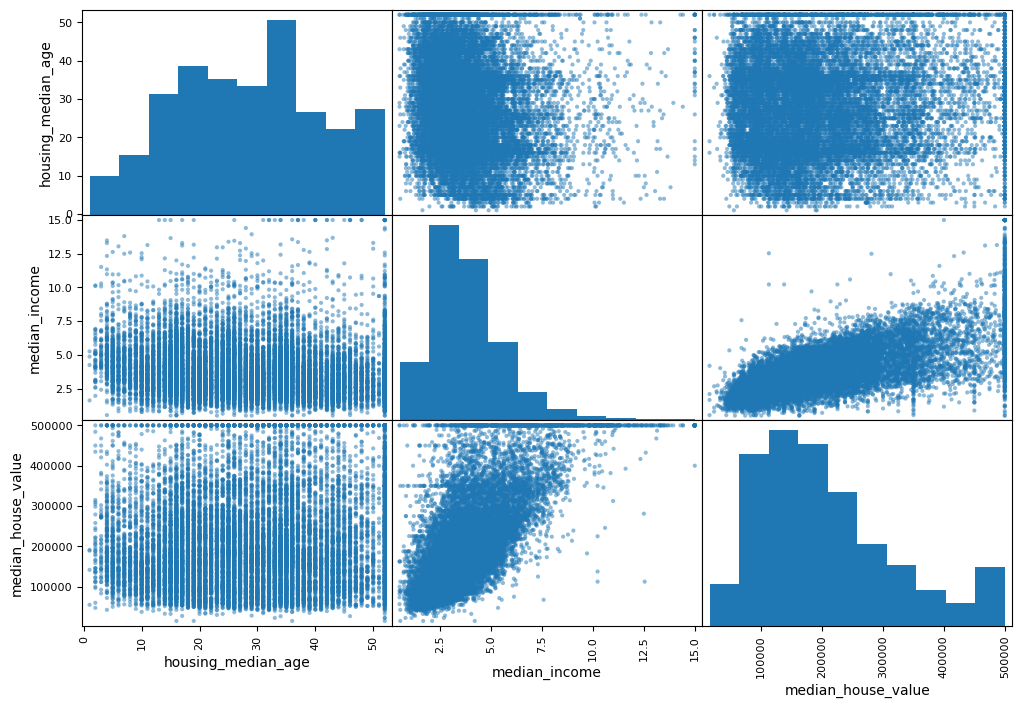

In [67]:
from pandas.plotting import scatter_matrix
attributes=["housing_median_age", "median_income","median_house_value"]
scatter_matrix(df[attributes],figsize=(12,8))